# Notebook 1: Function that automates evolution for cellular automata
## 1. Properties of binary numbers
In the decimal system, the number "xyz", is z * 10^0 + y * 10^1 + x * 10^2 and x, y, z are in the range between and including 0 and 9.

In the binary system, x, y and z are multiplied by 2^(1,2 or 3) and they can only be 0 or 1.

## 2. Cellular automata and elementary cellular automata
Cellular automata are a grid-based mathematical model where cells evolve over discrete time steps based on simple localised rules. The number of rules they can follow is quite large, and increases as the dimensions of the grid increases. In its most basic form, the grid is a one dimensional lattice and the state of a cell in the next timestep depends only on the states of the cell and its inmediate neighbors in the current timestep (markovian process). These are called elementary cellular automata.

### Elementary cellular automata
Elementary cellular automata have a state that is 0 or 1 sitting in a line and with a future state that depends on the cell it self and its neighbors. This evolution depends on 256 possible rules [0 - 255].

The rules come from the binary representation of the respective number, so the rule 0 (decimal) is 0000000 (binary). The rule number acts as a lookup table, as it explains what the middle cell will evolve into depending non the surrounding cells.

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import random 

In [3]:
def make_rule(rule_number: int) -> dict:
    if not (0 <= rule_number <= 255):
        raise ValueError(f"Rule number must be between 0 and 255, got {rule_number}")
 
    rule_bin = format(rule_number, '08b')  # e.g. rule 110 -> '01101110 (encode it into byts)' The decimal -> binary process explained above
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]  # '111' down to '000'
 
    return {n: int(b) for n, b in zip(neighbourhoods, rule_bin)}

In [4]:
print(make_rule(33))
print(make_rule(150))
print(make_rule(0))
print(make_rule(255))

{'111': 0, '110': 0, '101': 1, '100': 0, '011': 0, '010': 0, '001': 0, '000': 1}
{'111': 1, '110': 0, '101': 0, '100': 1, '011': 0, '010': 1, '001': 1, '000': 0}
{'111': 0, '110': 0, '101': 0, '100': 0, '011': 0, '010': 0, '001': 0, '000': 0}
{'111': 1, '110': 1, '101': 1, '100': 1, '011': 1, '010': 1, '001': 1, '000': 1}


We can also create a function that, when guven a rule number, it outputs the rule that has the oppossite mapping. For example the oppossite of rule 0 would be rule 255.

We can do this by taking the biany represnettaion of the rule number, turning the ones into zeros and vice versa and reconstructing the decimal number from that new binary number.

In [5]:
def complement_rule(rule_number: int) -> int:
    if not (0 <= rule_number <= 255):
        raise ValueError(f"Rule number must be between 0 and 255, got {rule_number}")

    rule_bin = format(rule_number, '08b')
    complement_bin = ''.join('1' if b == '0' else '0' for b in reversed(rule_bin))
    return int(complement_bin, 2)

In [19]:
for i in range(256):
    print(complement_rule(i))

255
127
191
63
223
95
159
31
239
111
175
47
207
79
143
15
247
119
183
55
215
87
151
23
231
103
167
39
199
71
135
7
251
123
187
59
219
91
155
27
235
107
171
43
203
75
139
11
243
115
179
51
211
83
147
19
227
99
163
35
195
67
131
3
253
125
189
61
221
93
157
29
237
109
173
45
205
77
141
13
245
117
181
53
213
85
149
21
229
101
165
37
197
69
133
5
249
121
185
57
217
89
153
25
233
105
169
41
201
73
137
9
241
113
177
49
209
81
145
17
225
97
161
33
193
65
129
1
254
126
190
62
222
94
158
30
238
110
174
46
206
78
142
14
246
118
182
54
214
86
150
22
230
102
166
38
198
70
134
6
250
122
186
58
218
90
154
26
234
106
170
42
202
74
138
10
242
114
178
50
210
82
146
18
226
98
162
34
194
66
130
2
252
124
188
60
220
92
156
28
236
108
172
44
204
76
140
12
244
116
180
52
212
84
148
20
228
100
164
36
196
68
132
4
248
120
184
56
216
88
152
24
232
104
168
40
200
72
136
8
240
112
176
48
208
80
144
16
224
96
160
32
192
64
128
0


Now that we have this function that takes each respective rule and decodes it. we can build up the function for the dynamics of the cellular automata.

Let's take a function that doesn't take the rule and just gives the structure of the grid without changing.

In [7]:
#For initial conditions, put in a list of integers that correspond to the position in the lattice where you
#want a one
def dynamics(L, initial_conditions, timesteps):
    row = np.zeros(L)
    for i in initial_conditions:
        row[i] = 1
    rows = [row]
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        rows.append(new_row)
    
    grid = np.vstack(rows[::-1])

    return(grid)

print(dynamics(7, (1,2,3), 4))
print(dynamics(10, (1,2,3, 5, 6, 7, 8,), 10))



[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0. 1. 1. 1. 1. 0.]]


Incorporating the code designating the rule and the inital conditions and evolution of the lattice. (assume neighboring cells are zero)

In [8]:
def dynamics(rule_number, L, initial_conditions, timesteps):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropiate")
    rule = make_rule(rule_number)

    row = np.zeros(L, dtype=int)
    for i in initial_conditions:
        row[i] = 1
    rows = [row.copy()]  # rows[0] = t=0, chronological order

    for _ in range(timesteps):
        prev = rows[-1]
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(prev[j-1])) if j > 0 else '0'
            centre = str(int(prev[j]))
            right  = str(int(prev[j+1])) if j < L-1 else '0'
            new_row[j] = rule[left+centre+right]
        rows.append(new_row)

    # t=0 at the bottom row (grid[-1]), last timestep at the top row (grid[0])
    grid = np.array(rows[::-1])
    return grid



print(dynamics(1, 10, (1,2,3,4), 5))
print(dynamics(0, 10, (1,2,3,4), 5))
print(dynamics(255, 10, (1,2,3,4), 5))

[[0 0 0 0 0 0 1 1 1 1]
 [1 1 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1]
 [1 1 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1]
 [0 1 1 1 1 0 0 0 0 0]]
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 1 0 0 0 0 0]]
[[1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 0 0 0 0 0]]


### Boundary cells - Most common ways of treating it

There are three main ways of dealing with boundary cells:
- Assume the neighboring cell is zero
- Imagine the lattice as a circumference 
- Take mirror symmetry with the other neighbour

Building up the code for the periodic case:

In [9]:
def dynamics_periodic(rule_number, L, initial_conditions, timesteps):
    # Building up the lookup table
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropiate")
    
    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)
    for i in initial_conditions:
        row[i] = 1
    rows = [row.copy()]

    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][(j - 1) % L]))  # periodic boundary
            center = str(int(rows[-1][j]))
            right  = str(int(rows[-1][(j + 1) % L]))
            neighbourhood = left + center + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return grid

print(dynamics(1, 10, (1,2,3,4), 5))
print(dynamics(0, 10, (1,2,3,4), 5))
print(dynamics(255, 10, (1,2,3,4), 5))

[[0 0 0 0 0 0 1 1 1 1]
 [1 1 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1]
 [1 1 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1]
 [0 1 1 1 1 0 0 0 0 0]]
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 1 1 1 1 0 0 0 0 0]]
[[1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 0 0 0 0 0]]


Building up the case for mirror symmetry:

In [10]:
def dynamics_reflection(rule_number, L, initial_conditions, timesteps):
    # Building up the lookup table
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropiate")
    
    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} #Previous function for the rule

    # Set up initial row
    row = np.zeros(L, dtype=int)
    for i in initial_conditions:
        row[i] = 1
    rows = [row.copy()]

    # Evolve through timesteps
    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][j + 1])) if j == 0 else str(int(rows[-1][j - 1]))  #mirror reflection
            center = str(int(rows[-1][j]))
            right  = str(int(rows[-1][j - 1])) if j == L - 1 else str(int(rows[-1][j + 1]))
            neighbourhood = left + center + right
            new_row[j] = rule[neighbourhood]
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return grid

print(dynamics(90, 5, (0,), 10))
print(dynamics(1, 5, (1,2,3,4), 1000))
print(dynamics(255, 10, (1,2,3,4), 5))

[[1 0 1 0 0]
 [0 1 0 0 0]
 [0 0 1 0 1]
 [0 0 0 1 0]
 [1 0 1 0 0]
 [0 1 0 0 0]
 [0 0 1 0 1]
 [0 0 0 1 0]
 [1 0 1 0 0]
 [0 1 0 0 0]
 [1 0 0 0 0]]
[[1 1 1 1 1]
 [0 0 0 0 0]
 [1 1 1 1 1]
 ...
 [1 1 1 1 1]
 [0 0 0 0 0]
 [0 1 1 1 1]]
[[1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 0 0 0 0 0]]


## 3. Turning numpy arrays into visual grids

[[0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [1 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]]


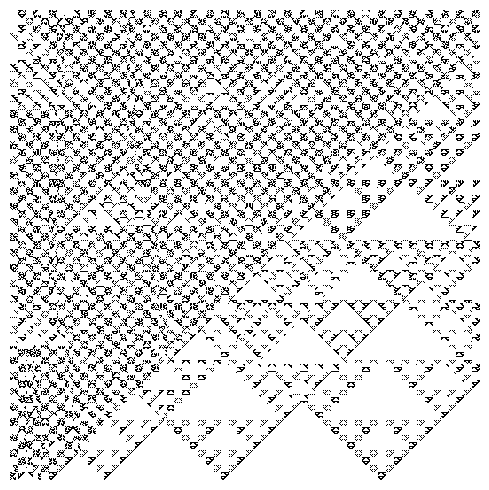

None


In [11]:
import matplotlib.pyplot as plt

def plot_grid(grid):
    plt.figure(figsize=(10, 5))
    plt.imshow(grid, cmap='binary', interpolation='nearest')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

arbitrary_grid = dynamics(18, 1000, [0, 10, 15, 63, 87, 54, 200, 453, 789], 1000) 
print(arbitrary_grid)
print(plot_grid(arbitrary_grid))

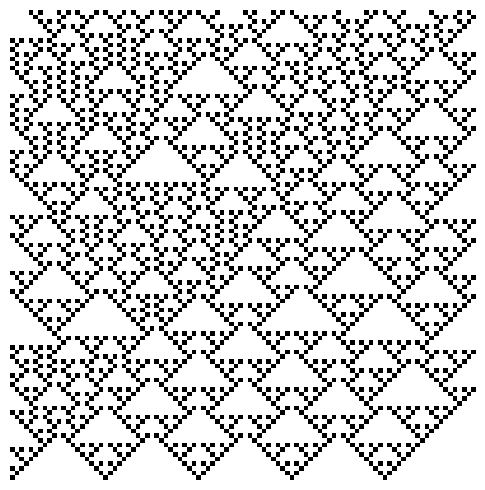

None


In [12]:
list = np.arange(0, 100, 20)
arbitrary_grid = dynamics(18, 100, list, 100)
print(plot_grid(arbitrary_grid))

## 4. Minimum set of rules + Dead cells with dead neighbors cannot give place to non-dead (128 rules)
Look at the dynamics code:

In [13]:
def dynamics(rule_number, L, initial_conditions, timesteps):
    if not (0 <= rule_number <= 255):
        raise ValueError("Rule number not appropiate")
    
    rule_bin = format(rule_number, '08b')
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]
    rule = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)} 

    row = np.zeros(L, dtype=int)
    for i in initial_conditions:
        row[i] = 1
    rows = [row.copy()]

    for i in range(timesteps):
        new_row = np.zeros(L, dtype=int)
        for j in range(L):
            left   = str(int(rows[-1][j + 1])) if j == 0 else str(int(rows[-1][j - 1]))  
            center = str(int(rows[-1][j]))
            right  = str(int(rows[-1][j - 1])) if j == L - 1 else str(int(rows[-1][j + 1]))
            neighbourhood = left + center + right
            if neighbourhood == "000":
                rule["000"] = 0
                new_row[j] = rule[neighbourhood]
            else:
                new_row[j] = rule[neighbourhood]
        
        rows.append(new_row)

    grid = np.vstack(rows[::-1])
    return grid

print(dynamics(230, 9, (1,2,3,4,5,6,7), 7)) #Some rules out of the 256 will be equal s.t. there are only 128 distinct rules, in this case the rules that 
# alr have a 0 ar 000 will remain unchanged whilst the ones that have a 1 at 000 will be affected.

[[1 1 1 1 1 1 1 0 1]
 [1 1 1 1 1 1 0 1 1]
 [1 1 1 1 1 0 1 1 1]
 [1 1 1 1 0 1 1 1 1]
 [1 1 1 0 1 1 1 1 1]
 [1 1 0 1 1 1 1 1 1]
 [1 0 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 0]]


In this case, the distinct number of rules will only be 128, so it is better to create a function to finds duplictaed rules (for example 110 and 111 will behave the same once 000 -> 0 is enforced), the process will be the following:
- Find the rules that are duplicted and remove them from the original set of rules

In [14]:
def get_unique_rules() -> dict:
    seen = {}
    unique = {}

    for i in range(256):
        rule = make_rule(i)
        rule['000'] = 0  # enforce empty space stays dead

        unique_rule = tuple(rule[n] for n in sorted(rule.keys()))

        if unique_rule not in unique:
            unique[unique_rule] = f"rule {i}"
        else:
            seen[unique_rule] = f"rule {i}"

    return (unique, seen)

unique_rules = get_unique_rules()[0]
duplicated_rules = get_unique_rules()[1]
print(f"Unique rules: {len(unique_rules.keys())}")  # 128
print(f"Duplicate rule numbers removed: {256 - len(unique_rules)}")
print(f"The unique rules are the following:", "\n", unique_rules)
print(f"The duplicated rules are the following:", "\n", duplicated_rules)


Unique rules: 128
Duplicate rule numbers removed: 128
The unique rules are the following: 
 {(0, 0, 0, 0, 0, 0, 0, 0): 'rule 0', (0, 1, 0, 0, 0, 0, 0, 0): 'rule 2', (0, 0, 1, 0, 0, 0, 0, 0): 'rule 4', (0, 1, 1, 0, 0, 0, 0, 0): 'rule 6', (0, 0, 0, 1, 0, 0, 0, 0): 'rule 8', (0, 1, 0, 1, 0, 0, 0, 0): 'rule 10', (0, 0, 1, 1, 0, 0, 0, 0): 'rule 12', (0, 1, 1, 1, 0, 0, 0, 0): 'rule 14', (0, 0, 0, 0, 1, 0, 0, 0): 'rule 16', (0, 1, 0, 0, 1, 0, 0, 0): 'rule 18', (0, 0, 1, 0, 1, 0, 0, 0): 'rule 20', (0, 1, 1, 0, 1, 0, 0, 0): 'rule 22', (0, 0, 0, 1, 1, 0, 0, 0): 'rule 24', (0, 1, 0, 1, 1, 0, 0, 0): 'rule 26', (0, 0, 1, 1, 1, 0, 0, 0): 'rule 28', (0, 1, 1, 1, 1, 0, 0, 0): 'rule 30', (0, 0, 0, 0, 0, 1, 0, 0): 'rule 32', (0, 1, 0, 0, 0, 1, 0, 0): 'rule 34', (0, 0, 1, 0, 0, 1, 0, 0): 'rule 36', (0, 1, 1, 0, 0, 1, 0, 0): 'rule 38', (0, 0, 0, 1, 0, 1, 0, 0): 'rule 40', (0, 1, 0, 1, 0, 1, 0, 0): 'rule 42', (0, 0, 1, 1, 0, 1, 0, 0): 'rule 44', (0, 1, 1, 1, 0, 1, 0, 0): 'rule 46', (0, 0, 0, 0, 1, 1, 0, 0)

To find an individual rule with this condition:

In [15]:
def make_rule_zero_condition(rule_number: int):
    if not (0 <= rule_number <= 255):
        raise ValueError(f"Rule number must be between 0 and 255, got {rule_number}")
 
    rule_bin = format(rule_number, '08b')  # e.g. rule 110 -> '01101110 (encode it into byts)' The decimal -> binary process explained above
    neighbourhoods = [format(i, '03b') for i in range(7, -1, -1)]  # '111' down to '000'
    
    results = {n: int(b) for n, b in zip(neighbourhoods, rule_bin)}
    results["000"] = 0
    return results

print(make_rule_zero_condition(109))
print(make_rule_zero_condition(255))

{'111': 0, '110': 1, '101': 1, '100': 0, '011': 1, '010': 1, '001': 0, '000': 0}
{'111': 1, '110': 1, '101': 1, '100': 1, '011': 1, '010': 1, '001': 1, '000': 0}


## 5. Minimum set of rules + Dead cells with dead neighbors cannot give place to non-dead + symmetry (32 rules)
Function for the rule number must be changed such that for example 110 and 011 map out the same output. rule["000"] = 0 is also enforced and there will only be 32 unique rules, this will have to be proved.

In [16]:
#Playing around with the rule code
def make_rule_symmetry(rule_number: int) -> dict:
    rule = make_rule_zero_condition(rule_number)

    i = -1
    for key in rule:
        inverted_key = key[::-1]
        i += 1
        if i == 4:
            break
        
        else:
            rule[inverted_key] = rule[key]

        
    return(rule)
        
        
print(make_rule_symmetry(98))
for i in range(256):
    rule = make_rule_symmetry(i)
    for keys in rule:
        inverted_key = keys[::-1]
        if rule[keys] != rule[inverted_key]:
            print(i, keys)
            raise ValueError("Algorithm incorrect.")
    if i == 255:
        print("The code works.")


{'111': 0, '110': 1, '101': 1, '100': 0, '011': 1, '010': 0, '001': 0, '000': 0}
The code works.


In [17]:
# For convenience we can create a function that outputs random initial conditions, only dependent on the lattice length, which will result useful for further functions
def random_ic(L):
    return np.random.randint(0, 2, size=L)

# ______

## Summary: The functions developed
- make_rule(number: int): The rule that the system will follow.
- dynamics(): Takes lattice size initial consitios and timsteeps, later rule was added, and shows how the system evolves through those timesteps.
- plot_grid(): Turns a grid into a binary plot.
- make_rule_zero_condition(): Like the function for the rule but imposes the condition that three dead cells cannot give place to a cell that is alive.
- make_rule_symmetry(): Like the function for the rule but imposes the condition that three dead cells cannot give place to a cell that is alive and also imposes symmetry.